## Домашнее задание №4. Данные и схемы валидации
### Проект: Сервис для сегментации опухолей на МРТ головного мозга с системой поиска похожих случаев

##### Источник и состав данных
Для проекта используется открытый набор данных LGG Segmentation Dataset с платформы Kaggle.
- *Источник*: изображения получены из базы The Cancer Imaging Archive (TCIA) и относятся к пациентам из The Cancer Genome Atlas (TCGA) с диагностированными глиомами низкой степени злокачественности.
- *Состав данных*: набор данных включает 2D-срезы магнитно-резонансной томографии (МРТ) головного мозга в формате  .tif.
- *Разметка*: предоставлены бинарные маски ручной экспертной сегментации, где 1 — пиксель относится к области аномалии, 0 - фон.

##### Проверим структуру датасета

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.io import imread
from tqdm import tqdm

DATA_PATH = "/Users/nastik/Downloads/archive/kaggle_3m"

images_paths = []
masks_paths = []

for root, dirs, files in os.walk(DATA_PATH):
    for name in files:
        if name.endswith('.tif'):
            if 'mask' in name:
                masks_paths.append(os.path.join(root, name))
            else:
                images_paths.append(os.path.join(root, name))

images_paths.sort()
masks_paths.sort()

print(f"Найдено изображений (МРТ): {len(images_paths)}")
print(f"Найдено масок (разметка): {len(masks_paths)}")

Найдено изображений (МРТ): 3929
Найдено масок (разметка): 3929


В датасете найдено ***3929*** МРТ-изображений и ***3929*** масок. Это означает, что разметка полная и количество масок в точности соответствует количеству снимков.

##### Анализируем количество пациентов и размеры изображений, чтобы понять, нужна ли нормализация по размеру

Анализ размеров изображений: 100%|██████████| 3929/3929 [00:03<00:00, 1067.40it/s]


Всего уникальных пациентов: 110


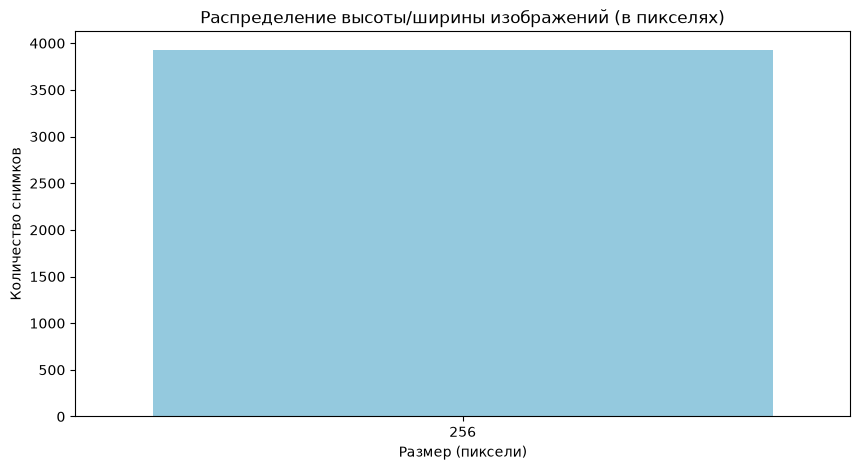

Уникальные размеры изображений в датасете:
   Height  Width  Channels
0     256    256         3


In [2]:
patient_ids = set()
image_shapes = []

for path in tqdm(images_paths, desc="Анализ размеров изображений"):
    patient_id = path.split(os.sep)[-2]
    patient_ids.add(patient_id)
    
    img = imread(path)
    image_shapes.append(img.shape)

print(f"Всего уникальных пациентов: {len(patient_ids)}")

df_shapes = pd.DataFrame(image_shapes, columns=['Height', 'Width', 'Channels'])

plt.figure(figsize=(10, 5))
sns.countplot(x='Height', data=df_shapes, color='skyblue')
plt.title("Распределение высоты/ширины изображений (в пикселях)")
plt.xlabel("Размер (пиксели)")
plt.ylabel("Количество снимков")
plt.show()

print("Уникальные размеры изображений в датасете:")
print(df_shapes.drop_duplicates())


В наборе данных представлены **110** пациентов, чьи снимки дают в сумме 3929 2D-срезов.
Гистограмма показала, что все изображения уже приведены к единому размеру **256×256** пикселей. Это особенность именно этого Kaggle датасета, так как авторы заранее сделали предобработку и привели снимки к стандартному формату. Это упрощает подготовку данных, дополнительная нормализация по размеру не требуется.

##### Проверим валидность изображений

In [3]:
black_images = 0
black_masks = 0

for path in tqdm(images_paths, desc="Проверка валидности изображений"):
    img = imread(path)
    if np.all(img == 0):
        black_images += 1

for path in tqdm(masks_paths, desc="Проверка валидности масок"):
    mask = imread(path, as_gray=True)
    if np.all(mask == 0):
        black_masks += 1

print(f"Полностью черных изображений: {black_images}")
print(f"Полностью черных масок: {black_masks}")


Проверка валидности масок: 100%|██████████| 3929/3929 [00:01<00:00, 2347.67it/s]

Полностью черных изображений: 0
Полностью черных масок: 2556


Полностью черные маски соответствуют тем срезам, на которых опухоль отсутствует (фон = 0). Хотя часть масок полностью нулевая (на этих срезах отсутствует опухоль), сами МРТ-снимки не являются пустыми: на них визуализируются структуры мозга без патологий. Это ситуация, когда опухоль занимает только часть 3D-объема, а остальные срезы пациента не содержат опухоль.

**Вывод:** битых или аномальных по структуре изображений в датасете не обнаружено, данные валидны для дальнейшего моделирования.

##### Проанализируем, насколько часто на срезах присутствует опухоль и какую площадь занимает маска

Анализ масок на дисбаланс: 100%|██████████| 3929/3929 [00:01<00:00, 2121.75it/s]


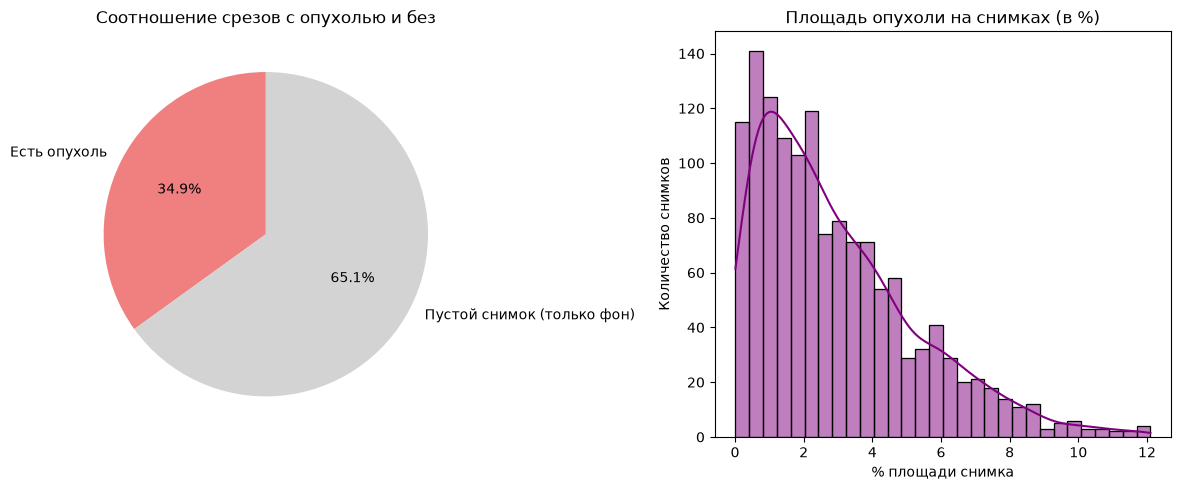

In [4]:
has_tumor_count = 0
empty_mask_count = 0
tumor_area_percentages = []

for path in tqdm(masks_paths, desc="Анализ масок на дисбаланс"):
    mask = imread(path, as_gray=True)
    
    total_pixels = mask.size
    tumor_pixels = np.sum(mask > 0)
    
    if tumor_pixels > 0:
        has_tumor_count += 1
        percentage = (tumor_pixels / total_pixels) * 100
        tumor_area_percentages.append(percentage)
    else:
        empty_mask_count += 1

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pie([has_tumor_count, empty_mask_count], 
        labels=['Есть опухоль', 'Пустой снимок (только фон)'], 
        autopct='%1.1f%%', colors=['lightcoral', 'lightgrey'], startangle=90)
plt.title("Соотношение срезов с опухолью и без")

plt.subplot(1, 2, 2)
sns.histplot(tumor_area_percentages, bins=30, kde=True, color='purple')
plt.title("Площадь опухоли на снимках (в %)")
plt.xlabel("% площади снимка")
plt.ylabel("Количество снимков")
plt.tight_layout()
plt.show()


Анализ показал, что около **65%** срезов не содержат опухоль, а на большинстве срезов c опухолью маска занимает менее **2–3%** площади изображения. Это создает сильный дисбаланс: если обучать модель на равномерной случайной выборке срезов, она будет видеть слишком много фона и слишком мало примеров с опухолью. Поэтому при обучении модели планируется использовать два приема: функцию потерь на основе Dice, которая лучше подходит для сегментации при дисбалансе классов, и усиленное сэмплирование срезов с опухолью при формировании батчей, чтобы модель чаще видела примеры с маской, а не только фон.

##### Проверим качество данных на конкретном примере, сопоставим МРТ-срез и соответствующую маску

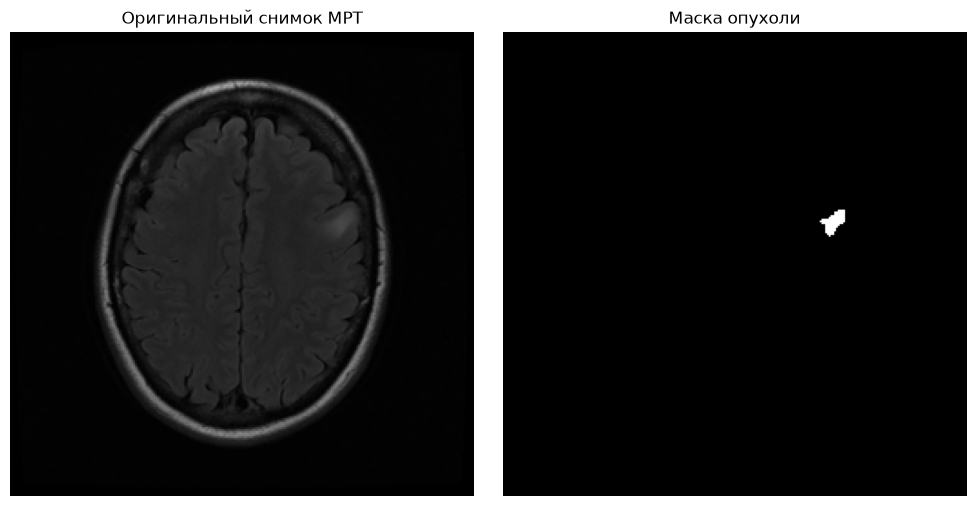

In [5]:
import random
random.seed(42)

positive_samples = []
for p in masks_paths:
    if np.sum(imread(p, as_gray=True) > 0) > 0:
        positive_samples.append(p)

sample_mask_path = random.choice(positive_samples)
sample_img_path = sample_mask_path.replace('_mask', '')

img = imread(sample_img_path)
mask = imread(sample_mask_path, as_gray=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('Оригинальный снимок МРТ')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Маска опухоли')
axes[1].axis('off')

plt.tight_layout()
plt.show()

По визуальному осмотру видно, что маска выделяет область повышенной интенсивности на снимке МРТ, соответствующую опухоли. Это подтверждает качество разметки.

##### Анализируем распределение яркости пикселей для разных МРТ (3 снимка)

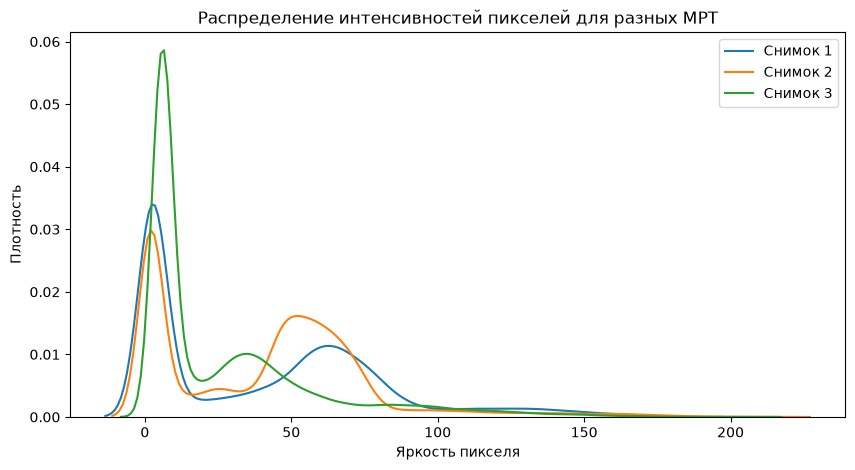

In [6]:
plt.figure(figsize=(10, 5))

sample_images = random.sample(images_paths, 3)

for i, path in enumerate(sample_images):
    img = imread(path)
    pixels = img[:,:,0].flatten()
    pixels_no_background = pixels[pixels > 0]
    
    sns.kdeplot(pixels_no_background, label=f"Снимок {i+1}")

plt.title("Распределение интенсивностей пикселей для разных МРТ")
plt.xlabel("Яркость пикселя")
plt.ylabel("Плотность")
plt.legend()
plt.show()


Разные изображения имеют разные распределения интенсивностей. Это свидетельствует о вариативности контраста и яркости между пациентами и аппаратами МРТ, поэтому при подготовке данных требуется нормализация интенсивностей.

##### Оценка качества разметки

По визуальному осмотру пары «МРТ‑срез + маска» маска корректно выделяет область аномалии на снимке. Полностью черные маски соответствуют срезам без опухоли, что является ожидаемой клинической ситуацией, а не ошибкой разметки. Разметка в датасете выполнена вручную на данных TCIA/TCGA и использовалась в научных работах по сегментации глиом низкой степени злокачественности.

На данном этапе дополнительное улучшение разметки не требуется.

##### Описание алгоритма формирования выборки и стратегии валидации

Для задачи медицинской сегментации важно исключить утечку данных между обучающей и валидационной выборками и учесть особенности данных.

- *Алгоритм формирования выборки*: исходный датасет сгруппирован по директориям, где каждая папка соответствует отдельному пациенту. Все 2D‑срезы и маски внутри папки принадлежат одному человеку. При подготовке данных следует формировать выборки именно на уровне пациентов, а не отдельных срезов.

- *Стратегия валидации*: используется разбиение по пациентам, а не по отдельным срезам. Каждый пациент целиком попадает либо в обучающую (train), либо в валидационную (validation) выборку. Это позволяет избежать ситуации, когда срезы одного и того же мозга оказываются одновременно в train и validation и искусственно завышают оценку качества модели.

- *Учет размера опухоли*: на этапе EDA было проанализировано, какую долю снимка в процентах обычно занимает опухоль. Выяснилось, что чаще всего маска очень маленькая, а большие опухоли встречаются редко. Каждый пациент дает несколько срезов: часть без опухоли, часть с небольшой маской, часть с более крупной. При разбиении по пациентам эти разные случаи попадают и в обучающую, и в валидационную выборки, поэтому модель обучается и проверяется сразу на примерах с разным размером опухоли.

- *Учет различий в интенсивностях*: EDA показал, что распределения яркости пикселей для разных МРТ‑снимков отличаются. Для сглаживания этих различий на этапе предобработки планируется нормализовать интенсивности, чтобы распределения интенсивностей в train и validation были сопоставимыми и разбиение по пациентам оставалось корректным.

- *Отбор валидации*: из общего количества 110 пациентов случайным образом (с фиксированным random seed для воспроизводимости) отбирается, например, 10 пациентов для валидационной выборки, а остальные используются для обучения. При необходимости схему можно расширить до k‑fold cross‑validation по пациентам, чтобы дополнительно оценить устойчивость результатов.
